# Implementação do solver para o Brasil usando o trabalho final de COS360 como base

## Imports

In [1]:
import pandas as pd
import pulp
import gcsfs
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv
from shapely import wkt

## Paths

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print(
        "Aviso: A variável GOOGLE_APPLICATION_CREDENTIALS não foi encontrada no arquivo .env"
    )
    print("O acesso ao GCS pode falhar.")

BUCKET_NAME = os.getenv('GCS_BUCKET_NAME')
STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
INPUT_PATH = f"gs://{BUCKET_NAME}/solver_inputs/candidatos_solver_brasil.csv"

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Carregamento de Dados

In [3]:
fs = gcsfs.GCSFileSystem()
with fs.open(INPUT_PATH) as f:
    df_candidatos = pd.read_csv(f, sep=';', decimal=',')

states_gdf = gpd.read_file(STATES_PATH)

print(f"Base carregada com {len(df_candidatos):,} latifúndios.")
print(f"Potencial Total Disponível: {df_candidatos['potencial_mw'].sum()/1000:.2f} GW")

C:\Users\JPMar\AppData\Local\Temp\ipykernel_29064\2647105353.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_candidatos = pd.read_csv(f, sep=';', decimal=',')


Base carregada com 419,133 latifúndios.
Potencial Total Disponível: 80215.13 GW


In [4]:
# Meta Nacional: 8.600 MW
META_MW = 8600 

## Modelagem do problema de otimização

### Modelo com custo do terreno, custo fixo de entrada na rede e limite superior de geração por terreno

In [5]:
print("Definindo restrições físicas e custos de mercado...")

# Definindo um faor de ocupação (área válida para instalação de painéis solares)
FATOR_OCUPACAO = 0.70
df_candidatos['area_efetiva_ha'] = df_candidatos['area_util_ha'] * FATOR_OCUPACAO

# Premissa NREL: 3.6 ha de painéis por MW
df_candidatos['potencial_mw_efetivo'] = df_candidatos['area_efetiva_ha'] / 3.6

# Custo Fundiário (OPEX de Arrendamento trazido a Valor Presente)
ARRENDAMENTO_HA_ANO = 1931
VIDA_UTIL_ANOS = 20
df_candidatos['custo_terra_rs'] = df_candidatos['area_util_ha'] * ARRENDAMENTO_HA_ANO * VIDA_UTIL_ANOS

# OPEX da TUST (Trazido a Valor Presente para 20 anos de vida útil)
TUST_KW_MES = 10.12
TUST_MW_ANO = (TUST_KW_MES * 1000) * 12
VIDA_UTIL_ANOS = 20
df_candidatos['custo_tust_rs'] = df_candidatos['potencial_mw_efetivo'] * TUST_MW_ANO * VIDA_UTIL_ANOS

# Custo Total do Projeto
df_candidatos['custo_total_projeto_rs'] = (
    df_candidatos['custo_conexao_rs'] + 
    df_candidatos['custo_terra_rs'] + 
    df_candidatos['custo_tust_rs']
)

Definindo restrições físicas e custos de mercado...


## Execução do solver sobre o modelo

### Solver para os três cenários do PDE

In [6]:
candidatos_localizacao = df_candidatos.copy()
df_candidatos.drop(columns='geometry', inplace=True)

In [7]:
# Definição das Metas
cenarios = {
    "Pessimista (80%)": META_MW * 0.8,
    "Referência (100%)": META_MW,
    "Otimista (120%)": META_MW * 1.2
}

resultados_cenarios = []
indices = df_candidatos.index

selecionados_cenarios = {}

solver = pulp.PULP_CBC_CMD(
    msg=True,
    gapRel=0.01,
    #, maxSeconds=300
    )

for nome_cenario, meta_mw in cenarios.items():
    print(f"Otimizando o cenário: {nome_cenario} (Meta: {meta_mw:.2f} MW)")
    
    # Iniciar o Problema
    prob = pulp.LpProblem(f"Otimizacao_Solar_BR_{nome_cenario[:3]}", pulp.LpMinimize)
    x = pulp.LpVariable.dicts(f"fazenda_{nome_cenario[:3]}", indices, cat='Binary')
    
    # Função Objetivo: Minimizar Custo Total
    prob += pulp.lpSum([df_candidatos.loc[i, 'custo_total_projeto_rs'] * x[i] for i in indices])
    
    # Restrição: Atingir a Meta (Potencial limitado a 300 MW por usina)
    prob += pulp.lpSum([df_candidatos.loc[i, 'potencial_mw_efetivo'] * x[i] for i in indices]) >= meta_mw
    
    prob.solve(solver)
    
    # Extrair métricas
    selecionados_idx = [i for i in indices if pulp.value(x[i]) == 1.0]
    df_selecionados = df_candidatos.loc[selecionados_idx]
    potencial_alocado = df_selecionados['potencial_mw_efetivo'].sum()
    custo_bilhoes = pulp.value(prob.objective) / 1e9
    selecionados_cenarios[nome_cenario] = df_selecionados

    resultados_cenarios.append({
        "Cenário": nome_cenario,
        "Meta PDE (MW)": meta_mw,
        "Alocado (MW)": potencial_alocado,
        "Fazendas Escolhidas": len(selecionados_idx),
        "Custo Total (R$ Bilhões)": round(custo_bilhoes, 3),
        "Custo Médio (R$ Milhões/MW)": round((custo_bilhoes * 1000) / potencial_alocado, 5)
    })
    print(f"    [Concluído] Status: {pulp.LpStatus[prob.status]}\n")

# Exibição do Balanço Final
print("="*100)
print("BALANÇO FINAL DE OTIMIZAÇÃO (BRASIL - PDE 2034)")
print("="*100)
df_resultados = pd.DataFrame(resultados_cenarios)
print(df_resultados.to_string(index=False))
# print(selecionados_cenarios["Pessimista (80%)"].to_string(index=False))
# print(selecionados_cenarios["Referência (100%)"].to_string(index=False))
# print(selecionados_cenarios["Otimista (120%)"].to_string(index=False))
print("="*100)

Otimizando o cenário: Pessimista (80%) (Meta: 6880.00 MW)
    [Concluído] Status: Optimal

Otimizando o cenário: Referência (100%) (Meta: 8600.00 MW)
    [Concluído] Status: Optimal

Otimizando o cenário: Otimista (120%) (Meta: 10320.00 MW)
    [Concluído] Status: Optimal

BALANÇO FINAL DE OTIMIZAÇÃO (BRASIL - PDE 2034)
          Cenário  Meta PDE (MW)  Alocado (MW)  Fazendas Escolhidas  Custo Total (R$ Bilhões)  Custo Médio (R$ Milhões/MW)
 Pessimista (80%)         6880.0   6880.401079                   37                    18.085                      2.62843
Referência (100%)         8600.0   8600.158205                   12                    22.598                      2.62760
  Otimista (120%)        10320.0  10320.096568                   23                    27.117                      2.62763


In [8]:
# selecionados_cenarios["Pessimista (80%)"].sort_values(by='nome_imovel', ascending=False)

In [9]:
candidatos_localizacao["geometry"] = candidatos_localizacao["geometry"].apply(wkt.loads)

In [10]:
fazendas_gdf = gpd.GeoDataFrame(candidatos_localizacao, geometry="geometry", crs="EPSG:5880")

In [11]:
fazendas_pessimista = fazendas_gdf.loc[selecionados_cenarios["Pessimista (80%)"].index]
fazendas_referencia = fazendas_gdf.loc[selecionados_cenarios["Referência (100%)"].index]
fazendas_otimista = fazendas_gdf.loc[selecionados_cenarios["Otimista (120%)"].index]

fazendas_pessimista = fazendas_pessimista.to_crs(states_gdf.crs)
fazendas_referencia = fazendas_referencia.to_crs(states_gdf.crs)
fazendas_otimista = fazendas_otimista.to_crs(states_gdf.crs)


In [12]:
# 1. Checagem de segurança: veja se não está vazio e que cara têm as coordenadas
print(f"Fazendas no dataframe: {len(fazendas_referencia)}")
print(fazendas_referencia.geometry.head())

Fazendas no dataframe: 12
3      POINT (-55.34356 -11.80181)
4       POINT (-36.53778 -8.99938)
33      POINT (-35.65085 -5.18688)
41       POINT (-56.5421 -20.2142)
298    POINT (-55.31802 -20.73941)
Name: geometry, dtype: geometry



Gerando mapa comparativo final de alocação espacial (PDE 2034)...


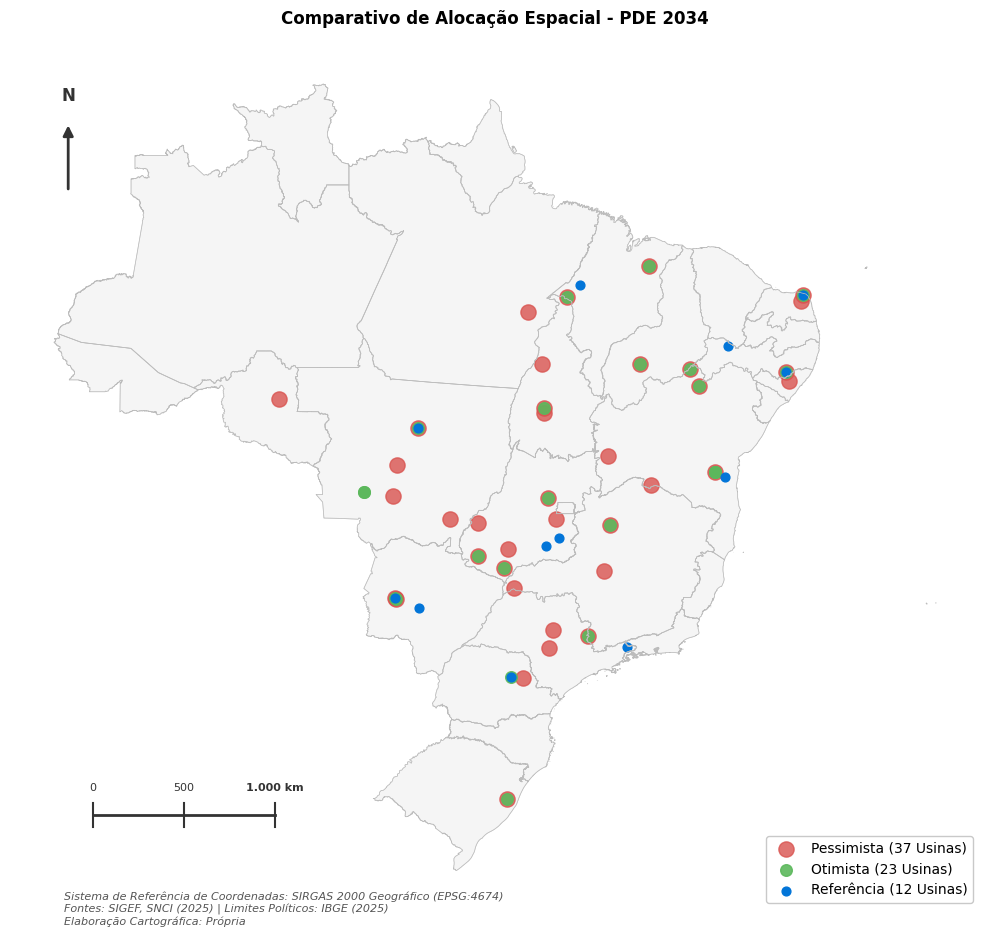

In [13]:
# Configuração de fontes para garantir textos reais pesquisáveis no PDF vetorial
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

print("\nGerando mapa comparativo final de alocação espacial (PDE 2034)...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1. Fundo do Brasil (Preenchimento cinza sutil e linhas de limite de estados discretas)
states_gdf.plot(ax=ax, color="#f5f5f5", edgecolor="#dcdcdc", linewidth=0.5, zorder=1)

# 2. Plota os cenários do maior conjunto (Pessimista - 37) para o menor (Referência - 12)
# Cores ajustadas para uma paleta sóbria e elegante de nível de publicação acadêmica
fazendas_pessimista.plot(
    ax=ax, color="#d9534f", markersize=120, label="Pessimista (37 Usinas)", alpha=0.8, zorder=2
)
fazendas_otimista.plot(
    ax=ax, color="#5cb85c", markersize=70, label="Otimista (23 Usinas)", alpha=0.9, zorder=3
)
fazendas_referencia.plot(
    ax=ax, color="#0275d8", markersize=40, label="Referência (12 Usinas)", alpha=1.0, zorder=4
)

# 3. Adiciona as bordas dos estados (mantido em formato vetorial puro para excelente contraste)
states_gdf.plot(ax=ax, color="none", edgecolor="#bcbcbc", linewidth=0.5, zorder=5)

# ==============================================================================
# ELEMENTOS CARTOGRÁFICOS RÍGIDOS (SIRGAS 2000, Decreto nº 89.817)
# ==============================================================================

# A. Indicador de Norte Minimalista (Seta limpa sem cauda)
# Afastado para a esquerda (x=0.06) para não interferir na divisa do Acre/Amazonas
ax.annotate('', xy=(0.06, 0.91), xytext=(0.06, 0.83),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle="-|>", color="#333333", lw=2.0, mutation_scale=15),
            ha='center', va='center')
ax.text(0.06, 0.93, 'N', transform=ax.transAxes, ha='center', va='bottom', 
        fontsize=12, weight='bold', color='#333333')

# B. Escala Gráfica de 1.000 km 
# Calculada para a latitude média do Brasil (15° S) no sistema EPSG:4674 (SIRGAS 2000)
# Onde 1 grau de longitude equivale a aproximadamente 107.5 km. 1.000 km ≈ 9.3 graus.
scale_x_start = -72.0
scale_x_mid = -67.35
scale_x_end = -62.70
scale_y = -31.0

# Desenha a linha da escala e seus respectivos ticks (marcações de limite)
ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y], color='#333333', linewidth=2.0)
ax.plot([scale_x_start, scale_x_start], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)
ax.plot([scale_x_mid, scale_x_mid], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)
ax.plot([scale_x_end, scale_x_end], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)

# Rótulos numéricos da escala gráfica
ax.text(scale_x_start, scale_y + 1.2, '0', ha='center', fontsize=8, color='#333333')
ax.text(scale_x_mid, scale_y + 1.2, '500', ha='center', fontsize=8, color='#333333')
ax.text(scale_x_end, scale_y + 1.2, '1.000 km', ha='center', fontsize=8, color='#333333', weight='bold')

# C. Metadados de Projeção, Datum, Escala Numérica e Classe (Decreto nº 89.817)
metadata_text = (
    "Sistema de Referência de Coordenadas: SIRGAS 2000 Geográfico (EPSG:4674)\n"
    "Fontes: SIGEF, SNCI (2025) | Limites Políticos: IBGE (2025)\n"
    "Elaboração Cartográfica: Própria"
)
ax.text(-73.5, -34.8, metadata_text, fontsize=8, style='italic', color='#555555', ha='left', va='top')

# ==============================================================================

# Customização da Legenda com moldura protetora (loc="lower right" evita colisão com a escala gráfica)
ax.legend(
    loc="lower right", 
    frameon=True,          # Mantém o quadro ativo
    facecolor="white",     # Fundo branco da caixa
    edgecolor="#bcbcbc",   # Borda cinza suave combinando com o padrão do trabalho
    fancybox=True,         # Cantos levemente arredondados para um visual moderno
    shadow=False, 
    fontsize=10
)

ax.set_title("Comparativo de Alocação Espacial - PDE 2034", fontsize=12, pad=15, weight='bold')
ax.set_axis_off()

plt.tight_layout()

# Salva a figura em formato PDF vetorial leve e de altíssima nitidez
plt.savefig(
    r"G:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\results\figures\mapa_resultados.pdf", 
    format="pdf", 
    bbox_inches="tight"
)
plt.savefig("../results/figures/mapa_resultados.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
set_pessimista = set(fazendas_pessimista.index)
set_referencia = set(fazendas_referencia.index)
set_otimista = set(fazendas_otimista.index)

print(f"Fazendas em comum (Pessimista x Otimista): {len(set_pessimista & set_otimista)}")
print(f"Fazendas em comum (Referência x Otimista): {len(set_referencia & set_otimista)}")
print(f"Fazendas em comum (Referência x Pessimista): {len(set_referencia & set_pessimista)}")
print(f"Fazendas que aparecem nos TRÊS cenários: {len(set_pessimista & set_referencia & set_otimista)}")

Fazendas em comum (Pessimista x Otimista): 18
Fazendas em comum (Referência x Otimista): 5
Fazendas em comum (Referência x Pessimista): 4
Fazendas que aparecem nos TRÊS cenários: 4
